# Argumentative Causal Discovery with LLMs - CauseNet Synthetic Data

Notebook collecting results for causal discovery algorithm ABAPC using additional constraints from LLMs.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import os
import sys
import numpy as np
from IPython.display import display
import pandas as pd
from scipy.stats import ttest_ind_from_stats
from itertools import combinations

pd.set_option('display.max_rows', 2000)

REPO_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'utils'))

from plotting import *

save_figs = os.environ.get('SAVE_FIGS', '0') == '1'
debug = False

RESULTS_DIR = REPO_ROOT / 'results'
PAPER_TAG = 'g2a01'
VERSION = 'test_rnd_spc'

names_dict = {
    'random': 'Random',
    'pc': 'PC',
    'pc_max': 'Max-PC',
    'fgs': 'FGS',
    'spc': 'Shapley-PC',
    'mpc': 'MPC',
    'mpc_llm': 'MPC-LLM',
    'cpc': 'CPC',
    'abapc': 'ABAPC',
    'abapc_llm': 'ABAPC-LLM-nd',
    'abapc_llm_d': 'ABAPC-LLM',
    'cam': 'CAM',
    'nt': 'NOTEARS-MLP',
    'mcsl': 'MCSL-MLP',
    'ges': 'GES',
    'aspcr': 'ASPCR',
    'llm_bfs': 'LLM-BFS',
    'grasp': 'GRaSP',
    'boss': 'BOSS',
}

symbols_dict = {
    'random': 'x',
    'pc': 'circle',
    'pc_max': 'circle-open',
    'fgs': 'triangle-up-dot',
    'spc': 'hexagon2-dot',
    'mpc': 'diamond-dot',
    'mpc_llm': 'diamond-open',
    'cpc': 'square-dot',
    'abapc': 'triangle-down-dot',
    'abapc_llm': 'triangle-down-open',
    'abapc_llm_d': 'triangle-left-open',
    'cam': 'star',
    'nt': 'pentagon-dot',
    'mcsl': 'cross-thin',
    'ges': 'circle-cross',
    'aspcr': 'diamond-open',
    'llm_bfs': 'square-open',
    'grasp': 'hourglass',
    'boss': 'bowtie',
}

colors_dict = {
    'random': '#7f7f7f',
    'pc': main_blue,
    'pc_max': sec_blue,
    'fgs': sec_orange,
    'spc': sec_green,
    'mpc': main_green,
    'mpc_llm': '#1b9e77',
    'cpc': '#c678dd',
    'abapc': "#7b7b12",
    'abapc_llm': sec_purple,
    'abapc_llm_d': main_purple,
    'cam': main_orange,
    'nt': sec_blue,
    'mcsl': '#bcbd22',
    'ges': '#17becf',
    'aspcr': sec_purple,
    'llm_bfs': "#e377c2", 
    'grasp': "#e1f85c",
    'boss': "#10430A",
}

inverse_names = {v: k for k, v in names_dict.items()}

default_methods = ['Random', 'PC', 'FGS', 'NOTEARS-MLP', 'GRaSP', 'BOSS', 'MPC', 'MPC-LLM', 'ABAPC', 'LLM-BFS', 'ABAPC-LLM']

runtime_methods = [m for m in names_dict.keys() if names_dict[m] in default_methods]
methods = default_methods.copy()

DATASET_LABEL_OVERRIDES = {
    # 'dag_10_nodes_10_edges_degrees_ER': 'ER<br>|V|=10 |E|=10',
}

DATASET_INCLUDE = []  # e.g. ['dag_10_nodes_10_edges_degrees_ER']
DATASET_EXCLUDE = []
HEURISTIC_INCLUDE = []
GRAPH_TYPE_INCLUDE = []
NODE_INCLUDE = []
EDGE_INCLUDE = []
DATASET_REGEX = None  # optional regex applied to dataset_id

AGGREGATE_BY_SIZE_TYPE = True
INCLUDE_HEURISTIC_IN_LABEL = False

HEURISTIC_LABELS = {
    'none': 'No Heuristic',
    'degrees': 'Degrees',
    'semantics': 'Semantics',
}

GRAPH_TYPE_LABELS = {
    'er': 'ER',
    'sf': 'SF',
    'random': 'LT',
    'lt': 'LT',
}

MODEL_ALIASES = {
}


EXTRA_MODELS = {}

RUN_CONFIGS = [
    {
        'results_dir': RESULTS_DIR,
        'version': 'test_rnd_spc',            # adjust to your first run
        'include_methods': ['Random'],
        'label': 'rnd_spc',
    },
    {
        'results_dir': RESULTS_DIR,
        'version': 'causenet_base',         # score/continuous baselines
        'include_methods': ['NOTEARS-MLP', 'FGS'],
        'label': 'nt_mpc_fgs',
    },
    {
        'results_dir': RESULTS_DIR,
        'version': f'causenet_mpc_desc_{PAPER_TAG}',
        'include_methods': ['MPC', 'MPC-LLM'],
        'label': 'mpc_mpc_llm_desc',
    },
    {
        'results_dir': RESULTS_DIR,
        'version': 'causenet_boss_grasp',         # adjust to your second run
        'include_methods': ['GRaSP', 'BOSS'],
        'label': 'grasp_boss',
    },
    {
        'results_dir': RESULTS_DIR,
        'format': 'csv',
        'csv_path': f'ABAPC-LLM/merged_synthetic-desc_{PAPER_TAG}.csv',
        'csv_model_column': 'impl',
        'csv_model_mapping': {
            'org': 'ABAPC',
            'new': 'ABAPC-LLM',
        },
        'include_methods': ['ABAPC', 'ABAPC-LLM'],
        'label': 'agg_csv_desc',
    },
    {
        'results_dir': RESULTS_DIR,
        'format': 'csv',
        'csv_path': 'causal-bfs-synthetic-results.csv',
        'csv_model_column': 'impl',
        'csv_model_mapping': {
            'llm-bfs': 'LLM-BFS',
        },
        'include_methods': ['LLM-BFS'],
        'label': 'agg_csv2',
    },
]


def parse_dataset_meta(dataset_id):
    parts = dataset_id.split('_')
    meta = {
        'dataset_id': dataset_id,
        'heuristic': None,
        'graph_type': None,
        'nodes': None,
        'edges': None,
    }
    try:
        if parts[0] == 'dag' and len(parts) >= 5:
            meta['nodes'] = int(parts[1])
            meta['edges'] = int(parts[3])
            if len(parts) >= 6:
                meta['heuristic'] = parts[5]
            if len(parts) >= 7:
                meta['graph_type'] = '_'.join(parts[6:])
    except (IndexError, ValueError):
        pass
    return meta

def size_type_label(n_nodes, n_edges, graph_type):
    graph_key = (str(graph_type).lower() if graph_type is not None else 'unknown')
    graph_label = GRAPH_TYPE_LABELS.get(graph_key, str(graph_type).replace('_', ' ').title() if graph_type is not None else 'Unknown')
    parts = []
    if pd.notna(n_nodes):
        parts.append(f"|V|={int(n_nodes)}")
    if pd.notna(n_edges):
        parts.append(f"|E|={int(n_edges)}")
    size_line = ' '.join(parts)
    return graph_label + (f"<br>{size_line}" if size_line else '')

def dataset_label_from_meta(meta):
    override = DATASET_LABEL_OVERRIDES.get(meta['dataset_id'])
    if override:
        return override
    base_label = size_type_label(meta.get('nodes'), meta.get('edges'), meta.get('graph_type'))
    if INCLUDE_HEURISTIC_IN_LABEL:
        heur = (meta.get('heuristic') or 'unknown').lower()
        heur_label = HEURISTIC_LABELS.get(heur, (meta.get('heuristic') or 'Unknown').replace('_', ' ').title())
        return f"{heur_label} - {base_label}"
    return base_label

def node_count_label(n_nodes):
    if pd.isna(n_nodes):
        return 'Unknown |V|'
    return f"|V|={int(n_nodes)}"


def graph_type_display(graph_type):
    if pd.isna(graph_type):
        return 'Unknown Type'
    key = str(graph_type).lower()
    ### replace random with LT
    if key == 'random':
        key = 'lt'
    return GRAPH_TYPE_LABELS.get(key, str(graph_type).replace('_', ' ').title())


def aggregate_metrics(df, group_cols, label_builder):
    if df.empty:
        return df.copy()
    required_cols = set(group_cols) | {'model', 'dataset_id'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'Missing columns for aggregation: {missing}')
    mean_cols = [col for col in df.columns if col.endswith('_mean')]
    std_cols = [col for col in df.columns if col.endswith('_std')]
    agg_dict = {col: 'mean' for col in mean_cols + std_cols}
    agg_dict['dataset_id'] = 'nunique'
    grouped = (
        df.groupby(group_cols + ['model'], dropna=False)
          .agg(agg_dict)
          .reset_index()
          .rename(columns={'dataset_id': 'graph_count'})
    )
    for col in ['n_nodes', 'n_edges']:
        if col in grouped:
            grouped[col] = pd.to_numeric(grouped[col], errors='coerce').astype('Int64')
    grouped['dataset_label'] = grouped.apply(label_builder, axis=1)
    grouped['dataset'] = grouped['dataset_label']
    grouped['graph_count'] = grouped['graph_count'].fillna(0).astype(int)
    return order_results(grouped)

def load_npy_table(path, columns):
    if not path.exists():
        raise FileNotFoundError(f'Missing results file: {path}')
    table = np.load(path, allow_pickle=True)
    df = pd.DataFrame(table, columns=columns)
    df['dataset'] = df['dataset'].astype(str)
    df['model'] = df['model'].astype(str)
    return df

COLUMNS_MAP = {
    'dag': ['dataset', 'model', 'elapsed_mean', 'elapsed_std', 'nnz_mean', 'nnz_std',
            'fdr_mean', 'fdr_std', 'tpr_mean', 'tpr_std', 'fpr_mean', 'fpr_std',
            'precision_mean', 'precision_std', 'recall_mean', 'recall_std',
            'F1_mean', 'F1_std', 'shd_mean', 'shd_std', 'sid_mean', 'sid_std'],
}

CSV_METRIC_MAP = {
    'dag': {
        'elapsed': 'time',
        'nnz': 'dag_nnz',
        'fdr': 'dag_fdr',
        'tpr': 'dag_tpr',
        'fpr': 'dag_fpr',
        'precision': 'dag_precision',
        'recall': 'dag_recall',
        'F1': 'dag_F1',
        'shd': 'dag_shd',
        'sid': 'dag_sid',
    }
}

def resolve_csv_path(spec, base_dir):
    csv_entry = spec.get('csv_path')
    if csv_entry is None:
        csv_entry = spec.get('csv_name', 'agg.csv')
    csv_path = Path(csv_entry)
    if not csv_path.is_absolute():
        csv_path = base_dir / csv_path
    return csv_path

def load_csv_results(kind, spec, columns, base_dir, csv_path=None):
    csv_path = csv_path or resolve_csv_path(spec, base_dir)
    if not csv_path.exists():
        raise FileNotFoundError(f'Missing CSV results file: {csv_path}')
    df = pd.read_csv(csv_path)
    dataset_col = spec.get('csv_dataset_column', 'dataset')
    model_col = spec.get('csv_model_column', 'model')
    df = df.rename(columns={dataset_col: 'dataset', model_col: 'model'})
    model_mapping = spec.get('csv_model_mapping')
    if model_mapping:
        df['model'] = df['model'].replace(model_mapping)
    df['dataset'] = df['dataset'].astype(str)
    df['model'] = df['model'].astype(str)
    metrics_map = CSV_METRIC_MAP[kind].copy()
    overrides = spec.get('csv_metric_map')
    if overrides:
        metrics_map.update(overrides)
    missing = [src for src in metrics_map.values() if src not in df.columns]
    if missing:
        raise ValueError(f'Missing columns in CSV results ({csv_path}): {missing}')
    rename_map = {src: name for name, src in metrics_map.items()}
    value_cols = list(rename_map.keys())
    df = df[['dataset', 'model'] + value_cols].rename(columns=rename_map)
    grouped = (
        df.groupby(['dataset', 'model'], as_index=False)
          .agg({col: ['mean', 'std'] for col in rename_map.values()})
    )
    flat_columns = []
    for col in grouped.columns:
        if isinstance(col, tuple):
            metric, agg = col
            if agg != '':
                flat_columns.append(f'{metric}_{agg}')
            else:
                flat_columns.append(metric)
        else:
            flat_columns.append(col)
    grouped.columns = flat_columns
    for metric in rename_map.values():
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        if mean_col not in grouped.columns:
            grouped[mean_col] = np.nan
        if std_col not in grouped.columns:
            grouped[std_col] = np.nan
    for col in columns:
        if col not in grouped.columns:
            print(f"Missing column in grouped results: {col}")
            grouped[col] = np.nan
    return grouped[columns]

def load_results(kind, run_specs=None):
    suffix = '_cpdag' if kind == 'cpdag' else ''
    columns = COLUMNS_MAP[kind]
    specs = run_specs or RUN_CONFIGS
    frames = []
    for spec in specs:
        base_dir = Path(spec.get('results_dir', RESULTS_DIR))
        include_methods = spec.get('include_methods')
        label = spec.get('label', spec.get('version', VERSION))
        fmt = str(spec.get('format', 'npy')).lower()
        if fmt == 'csv':
            csv_path = resolve_csv_path(spec, base_dir)
            if not csv_path.exists():
                print(f"[WARN] Missing results file: {csv_path}")
                continue
            df = load_csv_results(kind, spec, columns, base_dir, csv_path=csv_path)
        else:
            version = spec.get('version', VERSION)
            main_path = base_dir / f'stored_results_{version}{suffix}.npy'
            try:
                df = load_npy_table(main_path, columns)
            except FileNotFoundError:
                print(f"[WARN] Missing results file: {main_path}")
                continue

            for prefix, label_name in EXTRA_MODELS.items():
                extra_path = base_dir / f'stored_results_{prefix}_{version}{suffix}.npy'
                if extra_path.exists():
                    extra = load_npy_table(extra_path, columns)
                    extra['model'] = label_name
                    df = pd.concat([df, extra], ignore_index=True)

        df = df.rename(columns=lambda col: col.replace('sid', 'SID'))
        if 'model' in df:
            run_model_mapping = spec.get('model_mapping')
            if run_model_mapping:
                df['model'] = df['model'].replace(run_model_mapping)
            df['model'] = df['model'].replace(MODEL_ALIASES)
        if include_methods:
            df = df[df['model'].isin(include_methods)].reset_index(drop=True)
        df['run_label'] = label
        frames.append(df)

        ### rename random to LT in graph_type
        if 'graph_type' in df:
            df['graph_type'] = df['graph_type'].replace({'random': 'lt'})

    if not frames:
        cols_with_label = columns + ['run_label']
        return pd.DataFrame(columns=cols_with_label)

    return pd.concat(frames, ignore_index=True)

def annotate_results(df, normalise_targets):
    df = df.copy()
    df['dataset_id'] = df['dataset'].astype(str)
    meta_list = [parse_dataset_meta(ds) for ds in df['dataset_id']]
    meta_df = pd.DataFrame(meta_list)
    if not meta_df.empty:
        meta_df = meta_df.rename(columns={'nodes': 'n_nodes', 'edges': 'n_edges'})
        df = pd.concat([df, meta_df[['n_nodes', 'n_edges', 'heuristic', 'graph_type']]], axis=1)
    label_map = {m['dataset_id']: dataset_label_from_meta(m) for m in meta_list}
    df['dataset_label'] = df['dataset_id'].map(label_map)
    df['dataset'] = df['dataset_label']
    for col in ['n_nodes', 'n_edges']:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
    if 'n_edges' in df:
        denom = df['n_edges'].replace({0: pd.NA}).astype(float)
        for out_name, src_name in normalise_targets.items():
            mean_col = f'{src_name}_mean'
            std_col = f'{src_name}_std'
            if mean_col in df and std_col in df:
                df[f'p_{out_name}_mean'] = df[mean_col].astype(float) / denom
                df[f'p_{out_name}_std'] = df[std_col].astype(float) / denom
    return df

def order_results(df):
    if df.empty:
        return df.copy()
    order_cols = ['n_nodes', 'n_edges', 'heuristic', 'graph_type', 'dataset_id']
    available_cols = [col for col in order_cols if col in df]
    sort_df = df[available_cols + ['dataset_label']].drop_duplicates().sort_values(available_cols)
    categories = sort_df['dataset_label'].dropna().drop_duplicates().tolist()
    df = df.copy()
    df['dataset'] = pd.Categorical(df['dataset'], categories=categories, ordered=True)
    df.sort_values(['dataset', 'model'], inplace=True)
    df['dataset'] = df['dataset'].astype(str)
    df.reset_index(drop=True, inplace=True)
    return df

def prepare_results(kind, normalise_targets):
    df = load_results(kind)
    df = annotate_results(df, normalise_targets)
    df = order_results(df)
    return df

def aggregate_by_size_type(df):
    if df.empty:
        return df.copy()
    if not AGGREGATE_BY_SIZE_TYPE:
        df = df.copy()
        if 'dataset' not in df:
            if 'dataset_label' in df:
                df['dataset'] = df['dataset_label']
            else:
                df['dataset'] = df['dataset_id']
        if 'graph_count' not in df:
            df['graph_count'] = 1
        return order_results(df)
    return aggregate_metrics(
        df,
        ['n_nodes', 'n_edges', 'graph_type'],
        lambda row: size_type_label(row.get('n_nodes'), row.get('n_edges'), row.get('graph_type'))
    )


def aggregate_by_nodes(df):
    return aggregate_metrics(
        df,
        ['n_nodes'],
        lambda row: node_count_label(row.get('n_nodes'))
    )


def aggregate_by_graph_type(df):
    ## rename random to LT in graph_type
    if 'graph_type' in df:
        df['graph_type'] = df['graph_type'].replace({'random': 'lt'})
    return aggregate_metrics(
        df,
        ['graph_type'],
        lambda row: graph_type_display(row.get('graph_type'))
    )

def apply_dataset_selection(df):
    if df.empty:
        return df.copy()
    mask = pd.Series(True, index=df.index)
    if DATASET_INCLUDE:
        mask &= df['dataset_id'].isin(DATASET_INCLUDE)
    if DATASET_EXCLUDE:
        mask &= ~df['dataset_id'].isin(DATASET_EXCLUDE)
    if HEURISTIC_INCLUDE:
        mask &= df['heuristic'].isin(HEURISTIC_INCLUDE)
    if GRAPH_TYPE_INCLUDE:
        mask &= df['graph_type'].isin(GRAPH_TYPE_INCLUDE)
    if NODE_INCLUDE:
        mask &= df['n_nodes'].isin(NODE_INCLUDE)
    if EDGE_INCLUDE:
        mask &= df['n_edges'].isin(EDGE_INCLUDE)
    if DATASET_REGEX:
        mask &= df['dataset_id'].str.contains(DATASET_REGEX, regex=True, na=False)
    selected = df.loc[mask].copy()
    if selected.empty:
        return selected
    return order_results(selected)



In [2]:
required_files = []
for spec in RUN_CONFIGS:
    base_dir = Path(spec.get('results_dir', RESULTS_DIR))
    fmt = str(spec.get('format', 'npy')).lower()
    if fmt == 'csv':
        csv_path = resolve_csv_path(spec, base_dir)
        required_files.append((csv_path, True))
        continue
    version = spec.get('version', VERSION)
    required_files.append((base_dir / f'stored_results_{version}.npy', True))
    required_files.append((base_dir / f'stored_results_{version}_cpdag.npy', False))
    for prefix in EXTRA_MODELS:
        required_files.append((base_dir / f'stored_results_{prefix}_{version}.npy', False))
        required_files.append((base_dir / f'stored_results_{prefix}_{version}_cpdag.npy', False))

seen = set()
for path, required in required_files:
    if path in seen:
        continue
    seen.add(path)
    if path.exists():
        print(f"[found] {path}")
    elif required:
        print(f"[missing] {path}")



[found] /vol/bitbucket/fr920/ArgCausalDisco-worktrees/llm-uai2026-freeze/results/stored_results_test_rnd_spc.npy
[found] /vol/bitbucket/fr920/ArgCausalDisco-worktrees/llm-uai2026-freeze/results/stored_results_causenet_base.npy
[found] /vol/bitbucket/fr920/ArgCausalDisco-worktrees/llm-uai2026-freeze/results/stored_results_causenet_mpc_desc_g2a01.npy
[found] /vol/bitbucket/fr920/ArgCausalDisco-worktrees/llm-uai2026-freeze/results/stored_results_causenet_mpc_desc_g2a01_cpdag.npy
[found] /vol/bitbucket/fr920/ArgCausalDisco-worktrees/llm-uai2026-freeze/results/stored_results_causenet_boss_grasp.npy
[found] /vol/bitbucket/fr920/ArgCausalDisco-worktrees/llm-uai2026-freeze/results/stored_results_causenet_boss_grasp_cpdag.npy
[found] /vol/bitbucket/fr920/ArgCausalDisco-worktrees/llm-uai2026-freeze/results/ABAPC-LLM/merged_synthetic-desc_g2a01.csv
[found] /vol/bitbucket/fr920/ArgCausalDisco-worktrees/llm-uai2026-freeze/results/causal-bfs-synthetic-results.csv


In [3]:
from pathlib import Path
import csv
from statistics import median

def count_reps_for_run_configs(run_configs, results_dir):
    results = []
    # 1) For NPY runs, look for progress/<version>/*.csv with run-level rows
    for spec in run_configs:
        fmt = str(spec.get('format', 'npy')).lower()
        label = spec.get('label', spec.get('version', ''))
        if fmt == 'csv':
            # 2) For CSV runs, count unique seeds per (dataset, model)
            csv_path = spec.get('csv_path', spec.get('csv_name', 'agg.csv'))
            csv_path = Path(csv_path)
            if not csv_path.is_absolute():
                csv_path = Path(results_dir) / csv_path
            if not csv_path.exists():
                print(f"[WARN] Missing CSV results file: {csv_path}")
                continue
            with csv_path.open(newline='') as f:
                rows = list(csv.DictReader(f))
            model_key = 'model' if 'model' in rows[0] else 'impl' if 'impl' in rows[0] else None
            if not model_key:
                print(f"[WARN] CSV lacks model column: {csv_path}")
                continue
            model_mapping = spec.get('csv_model_mapping', {})
            def canon(m):
                if model_mapping:
                    return model_mapping.get(m, m)
                if model_key == 'impl':
                    return {'org': 'ABAPC', 'new': 'ABAPC-LLM-d'}.get(m, m)
                return m
            if not rows or 'seed' not in rows[0]:
                by_model = {}
                for r in rows:
                    ds = r.get('dataset', '')
                    m = canon(r.get(model_key, ''))
                    by_model.setdefault(m, set()).add(ds)
                for m, datasets in sorted(by_model.items()):
                    results.append({
                        'run': label, 'format': 'csv-summary', 'model': m,
                        'datasets': len(datasets), 'summary_only': True,
                    })
                continue
            reps_map = {}
            for r in rows:
                ds = r.get('dataset', '')
                m = canon(r.get(model_key, ''))
                s = r.get('seed', '')
                reps_map.setdefault((ds, m), set()).add(s)
            by_model = {}
            for (ds, m), seeds in reps_map.items():
                by_model.setdefault(m, []).append(len(seeds))
            for m, rep_list in sorted(by_model.items()):
                results.append({
                    'run': label, 'format': 'csv', 'model': m,
                    'datasets': len(rep_list),
                    'min': min(rep_list), 'median': int(median(rep_list)), 'max': max(rep_list),
                })
        else:
            version = spec.get('version')
            if not version:
                continue
            prog = Path(results_dir) / 'progress' / version
            if not prog.exists():
                for suffix, kind in [('', 'dag'), ('_cpdag', 'cpdag')]:
                    summary_path = Path(results_dir) / f'stored_results_{version}{suffix}.npy'
                    if not summary_path.exists():
                        continue
                    table = np.load(summary_path, allow_pickle=True)
                    if table.size == 0 or table.ndim != 2 or table.shape[1] < 2:
                        continue
                    df_summary = pd.DataFrame({'model': table[:, 1]})
                    for m, dataset_count in df_summary['model'].value_counts().sort_index().items():
                        results.append({
                            'run': label, 'format': 'npy-summary', 'model': m, 'kind': kind,
                            'datasets': int(dataset_count), 'summary_only': True,
                        })
                continue
            counts = []
            for p in prog.glob('*.csv'):
                kind = 'cpdag' if p.stem.endswith('_cpdag') else 'dag' if p.stem.endswith('_dag') else 'unknown'
                with p.open(newline='') as f:
                    rows = list(csv.DictReader(f))
                if not rows:
                    continue
                ds = rows[0].get('dataset', '')
                m = rows[0].get('model', '')
                reps = len(rows)
                counts.append((m, kind, ds, reps))
            by_model_kind = {}
            for m, kind, ds, reps in counts:
                by_model_kind.setdefault((m, kind), []).append(reps)
            for (m, kind), rep_list in sorted(by_model_kind.items()):
                results.append({
                    'run': label, 'format': 'npy', 'model': m, 'kind': kind,
                    'datasets': len(rep_list),
                    'min': min(rep_list), 'median': int(median(rep_list)), 'max': max(rep_list),
                })
    return results

# Use the same RUN_CONFIGS and RESULTS_DIR already defined in the notebook
rep_summaries = count_reps_for_run_configs(RUN_CONFIGS, RESULTS_DIR)
for r in rep_summaries:
    suffix = f" ({r['kind']})" if r.get('kind') else ''
    if r.get('summary_only'):
        print(f"{r['run']} {r['format']}: {r['model']}{suffix} -> datasets={r['datasets']}")
    else:
        print(f"{r['run']} {r['format']}: {r['model']}{suffix} -> datasets={r['datasets']}, min={r['min']}, median={r['median']}, max={r['max']}")


rnd_spc npy-summary: Random (dag) -> datasets=54
rnd_spc npy-summary: Shapley-PC (dag) -> datasets=54
nt_mpc_fgs npy-summary: FGS (dag) -> datasets=54
nt_mpc_fgs npy-summary: MPC (dag) -> datasets=54
nt_mpc_fgs npy-summary: NOTEARS-MLP (dag) -> datasets=54
mpc_mpc_llm_desc npy: MPC (cpdag) -> datasets=54, min=50, median=50, max=50
mpc_mpc_llm_desc npy: MPC (dag) -> datasets=54, min=50, median=50, max=50
mpc_mpc_llm_desc npy: MPC-LLM (cpdag) -> datasets=54, min=50, median=50, max=50
mpc_mpc_llm_desc npy: MPC-LLM (dag) -> datasets=54, min=50, median=50, max=50
grasp_boss npy-summary: BOSS (dag) -> datasets=54
grasp_boss npy-summary: GRaSP (dag) -> datasets=54
grasp_boss npy-summary: BOSS (cpdag) -> datasets=54
grasp_boss npy-summary: GRaSP (cpdag) -> datasets=54
agg_csv_desc csv: ABAPC -> datasets=53, min=50, median=50, max=50
agg_csv_desc csv: ABAPC-LLM -> datasets=53, min=50, median=50, max=50
agg_csv2 csv-summary: LLM-BFS -> datasets=54


## Structure Reconstruction Evaluation

In [4]:
dag_all = prepare_results('dag', {'shd': 'shd', 'SID': 'SID'})
dag_selected = apply_dataset_selection(dag_all)
if dag_selected.empty:
    raise ValueError('No datasets selected for DAG plots; adjust the dataset filters.')

dag_grouped = aggregate_by_size_type(dag_selected)

available_models_dag = dag_grouped['model'].unique().tolist()
methods = [m for m in default_methods if m in available_models_dag]

if 'p_SID_mean' in dag_grouped:
    dag_grouped['p_SID_mean'] = dag_grouped['p_SID_mean'].replace(0, 0.03)

dag_coverage = (
    dag_grouped
    .pivot_table(index='dataset', columns='model', values='graph_count', aggfunc='max', fill_value=0)
    .astype(int)
)
# display(dag_coverage)

dag_by_nodes = aggregate_by_nodes(dag_selected)
dag_by_graph_type = aggregate_by_graph_type(dag_selected)


In [5]:
if methods:
    if not dag_by_nodes.empty:
        double_bar_chart_plotly(
            dag_by_nodes,
            ['p_shd', 'F1'],
            names_dict,
            colors_dict,
            methods,
            save_figs=save_figs,
            output_name="../results/figs/Fig.8b_SHD_SID_dag_by_nodes.html",
            debug=False,
            range_y1=[0, 4],
            range_y2=[0, 1],
            font_size=23,
        )
        dag_nodes_coverage = (
            dag_by_nodes
            .pivot_table(index='dataset', columns='model', values='graph_count', aggfunc='max', fill_value=0)
            .astype(int)
        )
        bar_chart_plotly(
            dag_by_nodes,
            'p_SID',
            names_dict,
            colors_dict,
            methods,
            save_figs=save_figs,
            output_name="../results/figs/Fig.8b_SHD_SID_dag_by_nodes_F1.html",
            debug=False,
            font_size=23,
        )
        double_bar_chart_plotly(
            dag_by_nodes,
            ['precision', 'recall'],
            names_dict,
            colors_dict,
            methods,
            save_figs=save_figs,
            output_name="../results/figs/Fig.8b_SHD_SID_dag_by_nodes_precision_recall.html",
            debug=False,
            range_y1=[0, 1],
            range_y2=[0, 1],
            font_size=23,
        )
        display(dag_nodes_coverage)
    else:
        print('No DAG node-level aggregation available.')
    if not dag_by_graph_type.empty:
        double_bar_chart_plotly(
            dag_by_graph_type,
            ['p_shd', 'F1'],
            names_dict,
            colors_dict,
            methods,
            save_figs=save_figs,
            output_name="../results/figs/Fig.8c_SHD_SID_dag_by_type.html",
            debug=False,
            range_y1=[0, 4],
            range_y2=[0, 1],
            font_size=23,
        )
        bar_chart_plotly(
            dag_by_graph_type,
            'p_SID',
            names_dict,
            colors_dict,
            methods,
            save_figs=save_figs,
            output_name="../results/figs/Fig.8c_SHD_SID_dag_by_type_F1.html",
            debug=False,
            font_size=23,
        )
        double_bar_chart_plotly(
            dag_by_graph_type,
            ['precision', 'recall'],
            names_dict,
            colors_dict,
            methods,
            save_figs=save_figs,
            output_name="../results/figs/Fig.8c_SHD_SID_dag_by_type_precision_recall.html",
            debug=False,
            range_y1=[0, 1],
            range_y2=[0, 1],
            font_size=23,
        )

        dag_type_coverage = (
            dag_by_graph_type
            .pivot_table(index='dataset', columns='model', values='graph_count', aggfunc='max', fill_value=0)
            .astype(int)
        )
        display(dag_type_coverage)
    else:
        print('No DAG graph-type aggregation available.')
else:
    print('No methods configured for the grouped DAG plots.')


model,ABAPC,ABAPC-LLM,BOSS,FGS,GRaSP,LLM-BFS,MPC,MPC-LLM,NOTEARS-MLP,Random
dataset,,,,,,,,,,
|V|=10,18,18,18,18,18,18,18,18,18,18
|V|=15,18,18,18,18,18,18,18,18,18,18
|V|=5,17,17,18,18,18,18,18,18,18,18


model,ABAPC,ABAPC-LLM,BOSS,FGS,GRaSP,LLM-BFS,MPC,MPC-LLM,NOTEARS-MLP,Random
dataset,,,,,,,,,,
ER,17,17,18,18,18,18,18,18,18,18
LT,18,18,18,18,18,18,18,18,18,18
SF,18,18,18,18,18,18,18,18,18,18


### Table: NSHD and F1 by |V|
Mean +/- std using the same aggregated data as the node-level bar plot.


In [6]:
# Tabular summary for NSHD and F1 grouped by number of nodes
if methods and not dag_by_nodes.empty:
    metric_defs = {
        'NSHD': ('p_shd_mean', 'p_shd_std'),
        'F1': ('F1_mean', 'F1_std'),
    }

    node_order = (
        dag_by_nodes[['n_nodes', 'dataset']]
        .drop_duplicates()
        .sort_values('n_nodes')
        ['dataset']
        .tolist()
    )

    def format_metric_block(df, metric_name, mean_col, std_col):
        return (
            df[['model', 'dataset', mean_col, std_col]]
            .assign(metric=metric_name)
            .assign(value=lambda d: d.apply(
                lambda r: f"{r[mean_col]:.2f} +/- {r[std_col]:.2f}" if pd.notnull(r[mean_col]) else '–',
                axis=1,
            ))
            [['metric', 'model', 'dataset', 'value']]
        )

    table_long = pd.concat(
        [format_metric_block(dag_by_nodes, metric, *cols) for metric, cols in metric_defs.items()],
        ignore_index=True,
    )

    table = (
        table_long
        .pivot_table(index='model', columns=['metric', 'dataset'], values='value', aggfunc='first')
        .reindex(methods)
    )

    column_order = pd.MultiIndex.from_product([metric_defs.keys(), node_order])
    table = table.reindex(columns=column_order)

    styled = (
        table.style
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
        .set_caption('NSHD and F1 (mean +/- std) by |V| and method')
    )
    display(styled)
else:
    print('No DAG node-level aggregation available for table.')


### t-tests for difference in means

In [7]:
## Now perform t-tests between models on the aggregated results

## nobs should be the number of independent runs per model per dataset - 54 DAGs between 5,10,15 nodes, with 50 runs each. 50*(54/3) = 900

nobs = 50 * (54/3)
print("0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 'ns' 1.")
print(f"Using nobs={nobs} for t-tests.")

available_models = dag_grouped['model'].unique().tolist()
methods = [m for m in default_methods if m in available_models]
primary_methods = [m for m in ['Random', 'FGS', 'NOTEARS-MLP', 'MPC', 'MPC-LLM', 'ABAPC', 'ABAPC-LLM-d', 'GRaSP', 'BOSS'] if m in available_models]
models_for_tests = sorted(primary_methods)
print(models_for_tests)

if not models_for_tests:
    print('No models available for t-tests.')
else:
    def short_label(name):
        if 'ABAPC' in name and 'LLM' not in name:
            return 'APC'
        if 'ABAPC' in name and 'LLM' in name and '-d' not in name:
            return 'APC-LLM'
        if 'ABAPC' in name and 'LLM' in name and '-d' in name:
            return 'APC-LLM-d'
        if 'SPC' in name:
            return 'SPC'
        if 'NOTEARS' in name:
            return 'NT'
        if 'Random' in name:
            return 'RND'
        return name

var_groups = [
    ('p_shd', 'F1'),      # first plot
    # ('p_SID',),           # then SID
    # ('precision', 'recall'),  # then precision/recall
]
var_pretty = {
    'p_shd': 'NSHD',
    'p_SID': 'NSID',
    'F1': 'F1',
    'precision': 'Precision',
    'recall': 'Recall',
}

for dataset_label, dataset_rows in dag_by_nodes.groupby('dataset'):
    print(dataset_label.replace('<br>', ' ').upper())
    print('=' * 50)
    for group in var_groups:
        for var in group:
            mean_col = f'{var}_mean'
            std_col = f'{var}_std'
            if mean_col not in dataset_rows.columns or std_col not in dataset_rows.columns:
                continue
            print(var_pretty.get(var, var))
            for method1, method2 in combinations(models_for_tests, 2):
                rows1 = dataset_rows[dataset_rows['model'] == method1]
                rows2 = dataset_rows[dataset_rows['model'] == method2]
                if rows1.empty or rows2.empty:
                    continue
                a = rows1[mean_col].values[0]
                b = rows2[mean_col].values[0]
                a_std = rows1[std_col].values[0]
                b_std = rows2[std_col].values[0]
                if pd.isna(a) or pd.isna(b):
                    continue
                t, p = ttest_ind_from_stats(a, a_std, nobs, b, b_std, nobs, equal_var=False)
                sig = '' if p > 0.1 else '.' if p <= 0.1 and p > 0.05 else '*' if p <= 0.05 and p > 0.01 else '**' if p <= 0.01 and p > 0.001 else '***'
                label1 = short_label(method1)
                label2 = short_label(method2)
                # if var in ('F1', 'precision', 'recall'):
                a_str, a_std_str = f"{float(a):.2f}", f"{float(a_std):.2f}"
                b_str, b_std_str = f"{float(b):.2f}", f"{float(b_std):.2f}"
                # else:
                #     a_str, a_std_str = f"{float(a):.1f}", f"{float(a_std):.1f}"
                #     b_str, b_std_str = f"{float(b):.1f}", f"{float(b_std):.1f}"
                print(rf"\!\!\!{label1} $({a_str}\pm{a_std_str})$ \!v\! {label2} $({b_str}\pm{b_std_str})$ \!\!\!&\!\!\! {t:.3f} \!\!\!&\!\!\! {p:.3f}{sig} \\\\")
        print('')


0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 'ns' 1.
Using nobs=900.0 for t-tests.
['ABAPC', 'BOSS', 'FGS', 'GRaSP', 'MPC', 'MPC-LLM', 'NOTEARS-MLP', 'Random']
|V|=10
NSHD
\!\!\!APC $(0.48\pm0.11)$ \!v\! BOSS $(0.59\pm0.21)$ \!\!\!&\!\!\! -13.941 \!\!\!&\!\!\! 0.000*** \\\\
\!\!\!APC $(0.48\pm0.11)$ \!v\! FGS $(1.31\pm0.15)$ \!\!\!&\!\!\! -132.228 \!\!\!&\!\!\! 0.000*** \\\\
\!\!\!APC $(0.48\pm0.11)$ \!v\! GRaSP $(0.65\pm0.22)$ \!\!\!&\!\!\! -20.549 \!\!\!&\!\!\! 0.000*** \\\\
\!\!\!APC $(0.48\pm0.11)$ \!v\! MPC $(0.56\pm0.11)$ \!\!\!&\!\!\! -15.053 \!\!\!&\!\!\! 0.000*** \\\\
\!\!\!APC $(0.48\pm0.11)$ \!v\! MPC-LLM $(0.50\pm0.08)$ \!\!\!&\!\!\! -4.136 \!\!\!&\!\!\! 0.000*** \\\\
\!\!\!APC $(0.48\pm0.11)$ \!v\! NT $(1.00\pm0.01)$ \!\!\!&\!\!\! -137.774 \!\!\!&\!\!\! 0.000*** \\\\
\!\!\!APC $(0.48\pm0.11)$ \!v\! RND $(2.34\pm0.53)$ \!\!\!&\!\!\! -102.074 \!\!\!&\!\!\! 0.000*** \\\\
\!\!\!BOSS $(0.59\pm0.21)$ \!v\! FGS $(1.31\pm0.15)$ \!\!\!&\!\!\! -83.336 \!\!\!&\!\!\! 0.000*** \\\\
\!\!\!B

### BH Correction

In [8]:
from statsmodels.stats.multitest import multipletests

def sig_marker(p):
    return (
        '***' if p <= 0.001 else
        '**' if p <= 0.01 else
        '*' if p <= 0.05 else
        '.' if p <= 0.1 else
        'ns'
    )

records = []
for dataset_label, dataset_rows in dag_by_nodes.groupby('dataset'):
    for group in var_groups:
        for var in group:
            mean_col = f'{var}_mean'
            std_col = f'{var}_std'
            if mean_col not in dataset_rows.columns or std_col not in dataset_rows.columns:
                continue
            for method1, method2 in combinations(models_for_tests, 2):
                rows1 = dataset_rows[dataset_rows['model'] == method1]
                rows2 = dataset_rows[dataset_rows['model'] == method2]
                if rows1.empty or rows2.empty:
                    continue
                a, b = rows1[mean_col].values[0], rows2[mean_col].values[0]
                a_std, b_std = rows1[std_col].values[0], rows2[std_col].values[0]
                if pd.isna(a) or pd.isna(b):
                    continue
                t_stat, p_val = ttest_ind_from_stats(a, a_std, nobs, b, b_std, nobs, equal_var=False)
                records.append({
                    'dataset': dataset_label,
                    'metric': var,
                    'model_1': method1,
                    'model_2': method2,
                    't_stat': t_stat,
                    'p_value': p_val,
                    'marker_raw': sig_marker(p_val),
                    'summary': rf"\!\!\!{short_label(method1)} ({a:.2f}±{a_std:.2f}) v {short_label(method2)} ({b:.2f}±{b_std:.2f})",
                })

ttest_df = pd.DataFrame(records)

# Apply BH correction within each dataset/metric family of tests
ttest_df['p_bh'] = np.nan
ttest_df['reject_bh'] = False
for (dataset, metric), idx in ttest_df.groupby(['dataset', 'metric']).groups.items():
    reject, p_adj, _, _ = multipletests(ttest_df.loc[idx, 'p_value'], alpha=0.05, method='fdr_bh')
    ttest_df.loc[idx, 'p_bh'] = p_adj
    ttest_df.loc[idx, 'reject_bh'] = reject
ttest_df['marker_bh'] = ttest_df['p_bh'].apply(sig_marker)

# Pretty print
for (dataset, metric), sub in ttest_df.groupby(['dataset', 'metric']):
    print(dataset.replace('<br>', ' ').upper())
    print(metric.upper())
    for _, row in sub.sort_values('p_value').iterrows():
        print(f"{row['summary']} :: t={row['t_stat']:.3f} p={row['p_value']:.3g}{row['marker_raw']} "
              f"| p_BH={row['p_bh']:.3g}{row['marker_bh']}{' (rej)' if row['reject_bh'] else ''}")
    print('-' * 60)


|V|=10
F1
\!\!\!APC (0.61±0.11) v FGS (0.17±0.07) :: t=103.968 p=0*** | p_BH=0*** (rej)
\!\!\!BOSS (0.58±0.17) v FGS (0.17±0.07) :: t=66.721 p=0*** | p_BH=0*** (rej)
\!\!\!APC (0.61±0.11) v RND (0.19±0.08) :: t=90.720 p=0*** | p_BH=0*** (rej)
\!\!\!APC (0.61±0.11) v NT (0.16±0.00) :: t=123.639 p=0*** | p_BH=0*** (rej)
\!\!\!BOSS (0.58±0.17) v RND (0.19±0.08) :: t=60.309 p=0*** | p_BH=0*** (rej)
\!\!\!FGS (0.17±0.07) v GRaSP (0.54±0.18) :: t=-58.938 p=0*** | p_BH=0*** (rej)
\!\!\!FGS (0.17±0.07) v MPC (0.58±0.10) :: t=-104.489 p=0*** | p_BH=0*** (rej)
\!\!\!BOSS (0.58±0.17) v NT (0.16±0.00) :: t=73.116 p=0*** | p_BH=0*** (rej)
\!\!\!FGS (0.17±0.07) v MPC-LLM (0.63±0.08) :: t=-136.059 p=0*** | p_BH=0*** (rej)
\!\!\!GRaSP (0.54±0.18) v NT (0.16±0.00) :: t=64.649 p=0*** | p_BH=0*** (rej)
\!\!\!MPC-LLM (0.63±0.08) v RND (0.19±0.08) :: t=114.015 p=0*** | p_BH=0*** (rej)
\!\!\!MPC-LLM (0.63±0.08) v NT (0.16±0.00) :: t=181.900 p=0*** | p_BH=0*** (rej)
\!\!\!MPC (0.58±0.10) v RND (0.19±0.08) ::

## Constraints Evaluation

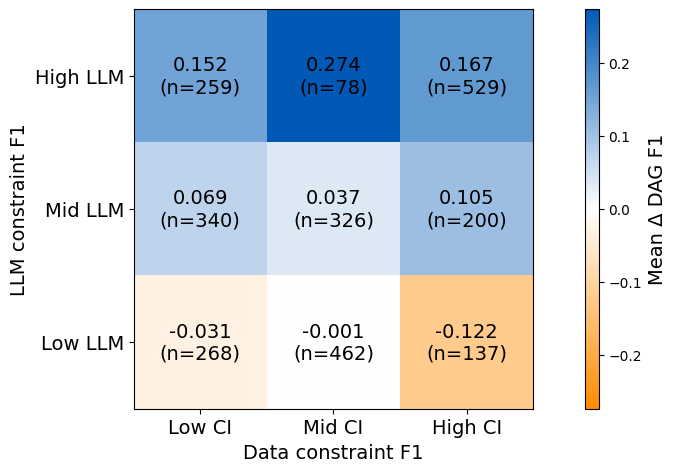

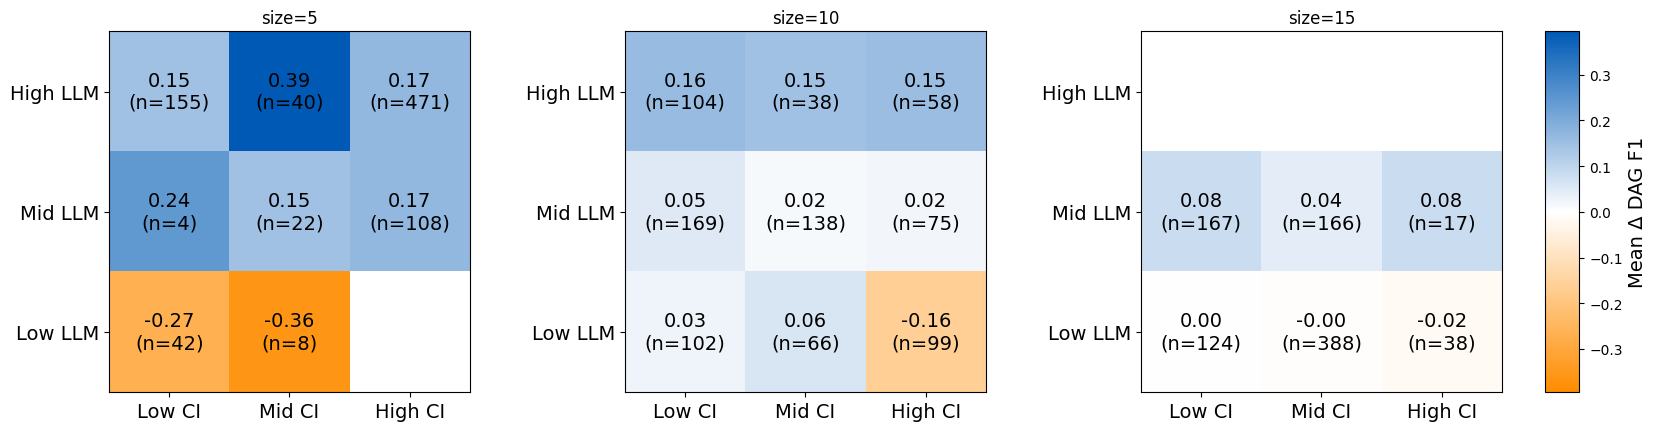

[GLOBAL] do per-size counts sum to aggregate?  True
CI edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]
LLM edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]


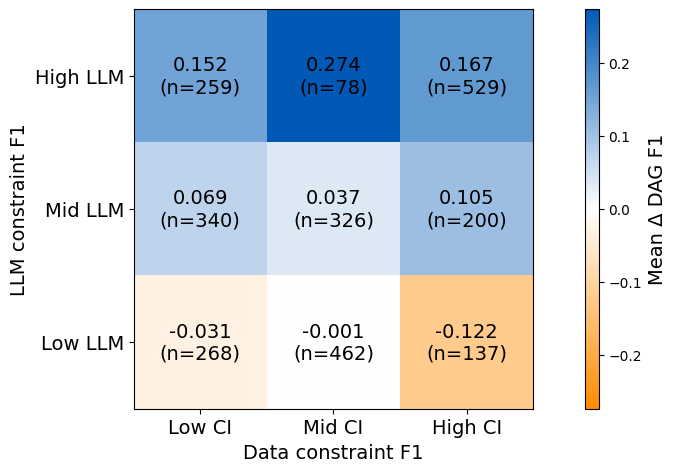

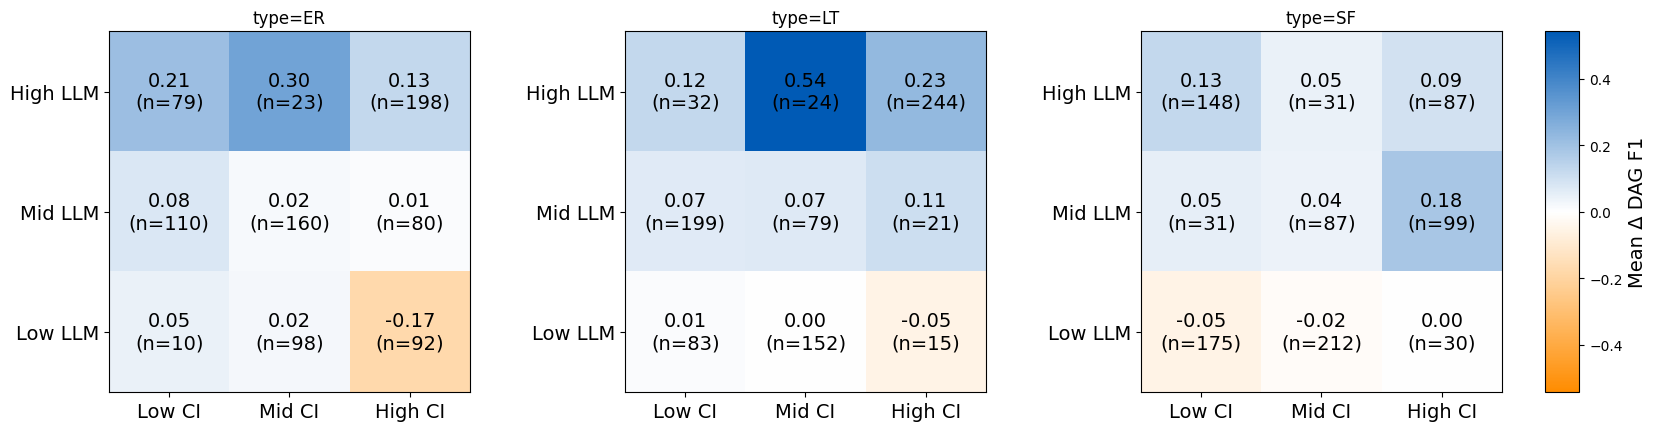

[GLOBAL] do per-type counts sum to aggregate?  True
CI edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]
LLM edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]


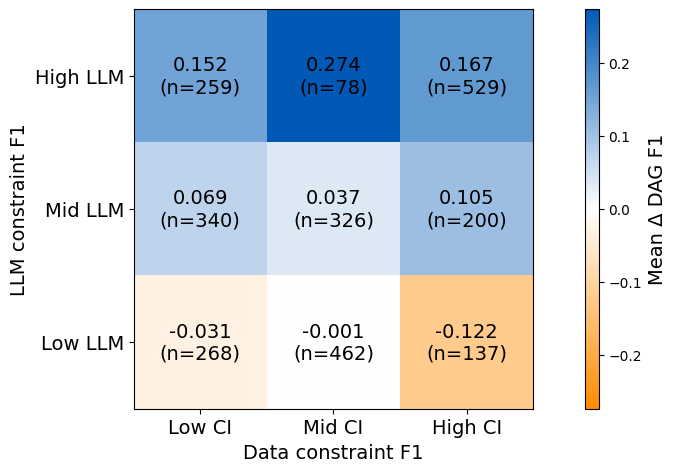

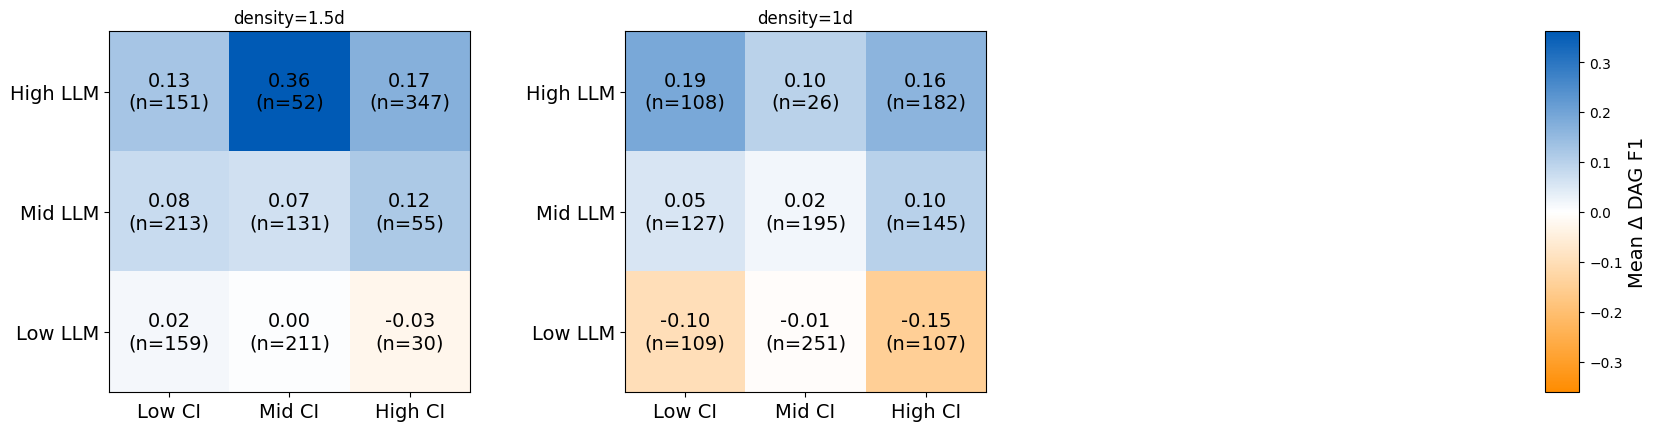

[GLOBAL] do per-density counts sum to aggregate?  True
CI edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]
LLM edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]


In [9]:
# Heatmaps for synthetic data with split by dataset, size, type, or density.
# - Robust, tie-safe quantile binning (right-inclusive) with a GLOBAL_BINS switch.
# - Factors parsed from synthetic dataset names: size, type (ER/SF/random/other), density (1d/1.5d/other).
# - Plots: one aggregated heatmap + a panel grid split by the chosen factor.
#
# Usage example:
#   INPATH = "/path/to/merged_synthetic-desc_g2a01.csv"
#   run_synth_heatmaps(INPATH, split_by="size", GLOBAL_BINS=True)     # or "dataset" / "type" / "density"
#   run_synth_heatmaps(INPATH, split_by="type", GLOBAL_BINS=False)

import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

# -------------------- helpers --------------------

def cmap_blue_good_orange_bad():
    return LinearSegmentedColormap.from_list(
        "good_blue_bad_orange",
        [(255/255,140/255,0/255), (1,1,1), (0/255,90/255,181/255)],
        N=256
    )

def tie_safe_qbins(series, q=3, right=True):
    """Quantile bins on rank-normalized values; right-inclusive to keep max inside last bin."""
    s = pd.to_numeric(series, errors="coerce")
    ranks = s.rank(method="first")                    # stable, unique ranks
    norm = ranks / (ranks.max() if ranks.max() else 1)
    edges = np.quantile(norm, np.linspace(0,1,q+1))
    if right:
        edges[-1] = 1.0                              # include the max
    labels = ["Low","Mid","High"][:q]
    bins = pd.cut(norm, bins=edges, labels=labels, include_lowest=True,
                  right=right, duplicates="drop")
    return bins, edges

def grid_counts_and_means(df_in, row_labcol, col_labcol, val_col):
    rows = ["High","Mid","Low"]   # plot top→bottom
    cols = ["Low","Mid","High"]   # plot left→right
    means = np.full((3,3), np.nan); counts = np.zeros((3,3), dtype=int)
    for i, rlab in enumerate(rows):
        for j, clab in enumerate(cols):
            vals = df_in.loc[(df_in[row_labcol]==rlab) & (df_in[col_labcol]==clab), val_col].astype(float)
            if len(vals)>0:
                means[i,j] = float(vals.mean())
                counts[i,j] = int(len(vals))
    return means, counts

def parse_synth_fields(name: str):
    """Extract size, graph type, and density from synthetic dataset name."""
    size = None; gtype="other"; density=None
    m = re.search(r"_(\d+)_nodes", name);  size = int(m.group(1)) if m else None
    if "ER" in name: gtype = "ER"
    elif "SF" in name: gtype = "SF"
    elif "random" in name.lower(): gtype = "LT"
    m2 = re.search(r"_(\d+)_edges", name)
    if m2 and size:
        edges = int(m2.group(1)); ratio = edges/float(size)
        if abs(ratio-1.0) < 0.2: density = "1d"
        elif abs(ratio-1.5) < 0.3: density = "1.5d"
        else: density = f"{ratio:.1f}d"
    return size, gtype, density

def build_run_table(df_raw: pd.DataFrame):
    """Aggregate per (dataset,seed,impl), merge org/new, compute ΔF1, and append factors."""
    # LLM quality
    if {"prior_forbidden_F1","prior_required_F1"} <= set(df_raw.columns):
        df_raw["prior_overall_F1"] = df_raw[["prior_forbidden_F1","prior_required_F1"]].mean(axis=1)
    LLM_COL = next((c for c in ["prior_overall_F1","AP_F1","prior_required_F1",
                                "prior_forbidden_F1","prior_forbidden_Precision","AP"]
                    if c in df_raw.columns), None)

    # CI quality: prefer CIT_F1; fallback F1(P,R); else R then P
    def row_ciq(row):
        if "CIT_F1" in row and pd.notna(row["CIT_F1"]):
            return row["CIT_F1"]
        p = row.get("CIT_Precision"); r = row.get("CIT_Recall")
        if pd.notna(p) and pd.notna(r) and (p+r)>0: return 2*p*r/(p+r)
        if pd.notna(r): return r
        if pd.notna(p): return p
        return np.nan

    df_raw["CIQ"] = df_raw.apply(row_ciq, axis=1).clip(0,1)

    keep = ["dataset","seed","impl","num_nodes","CIQ",LLM_COL,"dag_F1"]
    df = df_raw[keep].copy()

    avg = df.groupby(["dataset","seed","impl"], as_index=False).mean(numeric_only=True)

    org = avg[avg["impl"]=="org"].drop(columns=["impl"]).rename(columns={"CIQ":"ci_quality"})
    new = avg[avg["impl"]=="new"].drop(columns=["impl"]).rename(columns={"CIQ":"ci_quality_new", LLM_COL:"llm_quality"})
    merged = pd.merge(new, org, on=["dataset","seed"], how="inner", suffixes=("_new","_org"))
    merged["n_nodes"] = merged["num_nodes_new"].fillna(merged["num_nodes_org"])

    m = merged[["dataset","seed","n_nodes","ci_quality","llm_quality","dag_F1_new","dag_F1_org"]].copy()
    m = m.rename(columns={"dag_F1_new":"comb","dag_F1_org":"ci"})
    m["delta"] = m["comb"] - m["ci"]
    m = m.dropna(subset=["ci_quality","llm_quality","delta"])

    # factors
    parsed = m["dataset"].apply(parse_synth_fields)
    m["size"]    = [p[0] for p in parsed]
    m["type"]    = [p[1] for p in parsed]
    m["density"] = [p[2] for p in parsed]
    return m

def plot_agg(means, counts, title_suffix):
    vmax = np.nanmax(np.abs(means)) if np.any(~np.isnan(means)) else 1.0
    fig = plt.figure(figsize=(6.8,5.4))
    ax = fig.add_axes([0.12,0.16,0.66,0.74])
    im = ax.imshow(means, cmap=cmap_blue_good_orange_bad(), norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax), aspect="equal")
    ax.set_xticks(range(3)); ax.set_xticklabels(["Low CI","Mid CI","High CI"], fontsize=14)
    ax.set_yticks(range(3)); ax.set_yticklabels(["High LLM","Mid LLM","Low LLM"], fontsize=14)
    ax.set_xlabel("Data constraint F1", fontsize=14)
    ax.set_ylabel("LLM constraint F1", fontsize=14)
    for i in range(3):
        for j in range(3):
            if not np.isnan(means[i,j]):
                ax.text(j,i,f"{means[i,j]:.3f}\n(n={counts[i,j]})", ha="center", va="center", fontsize=14)
    cax = fig.add_axes([0.82,0.16,0.02,0.74]); cb = fig.colorbar(im, cax=cax); cb.set_label("Mean Δ DAG F1", fontsize=14)
    # ax.set_title(f"dag_F1 — {title_suffix}", fontsize=14)
    plt.show()

def plot_panels(panels, split_by):
    n = len(panels); ncols=3; nrows=math.ceil(n/ncols)
    fig = plt.figure(figsize=(5.0*ncols+2.2, 4.4*nrows))
    left, right, top, bottom = 0.05, 0.11, 0.08, 0.10
    wspace, hspace = 0.06, 0.09
    grid_w = 1 - left - right; grid_h = 1 - top - bottom
    cell_w = (grid_w - (ncols-1)*wspace)/ncols; cell_h = (grid_h - (nrows-1)*hspace)/nrows

    vmax=0.0
    for _, means, _ in panels:
        if np.any(~np.isnan(means)):
            vmax = max(vmax, np.nanmax(np.abs(means)))
    if vmax==0: vmax=1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    for idx, (label, means, counts) in enumerate(panels):
        r = idx//ncols; c = idx % ncols
        ax = fig.add_axes([left + c*(cell_w+wspace), 1 - top - (r+1)*cell_h - r*hspace, cell_w, cell_h])
        im = ax.imshow(means, cmap=cmap_blue_good_orange_bad(), norm=norm, aspect="equal")
        ax.set_xticks(range(3)); ax.set_xticklabels(["Low CI","Mid CI","High CI"], fontsize=14)
        ax.set_yticks(range(3)); ax.set_yticklabels(["High LLM","Mid LLM","Low LLM"], fontsize=14)
        ax.set_title(f'{split_by}={label}', fontsize=12)
        for i in range(3):
            for j in range(3):
                if not np.isnan(means[i,j]):
                    ax.text(j,i,f"{means[i,j]:.2f}\n(n={counts[i,j]})", ha="center", va="center", fontsize=14)
    cax = fig.add_axes([1-right+0.01, bottom, 0.02, grid_h]); cb = fig.colorbar(im, cax=cax); cb.set_label("Mean Δ DAG F1", fontsize=14)
    # fig.suptitle(f"dag_F1 — {title_suffix}", fontsize=15, y=0.995)
    plt.show()

# -------------------- main entry --------------------

def run_synth_heatmaps(INPATH, split_by="size", GLOBAL_BINS=True):
    """
    INPATH: path to your synthetic CSV (same columns as before).
    split_by: "dataset", "size", "type", or "density".
    GLOBAL_BINS: True = one set of Low/Mid/High edges reused across all panels,
                 False = cuts recomputed independently per panel.
    """
    df_raw = pd.read_csv(INPATH)
    m = build_run_table(df_raw)

    if split_by not in {"dataset","size","type","density"}:
        raise ValueError("split_by must be one of: 'dataset', 'size', 'type', 'density'")

    groups = sorted(m[split_by].dropna().unique().tolist())

    if GLOBAL_BINS:
        # Global cuts
        m["ci_bin"], ci_edges  = tie_safe_qbins(m["ci_quality"],  q=3, right=True)
        m["llm_bin"], llm_edges = tie_safe_qbins(m["llm_quality"], q=3, right=True)
        # Aggregated heatmap
        agg_means, agg_counts = grid_counts_and_means(m, "llm_bin", "ci_bin", "delta")
        plot_agg(agg_means, agg_counts, "GLOBAL cuts — aggregated")
        # Panels with the same cuts
        panels=[]; sum_counts=np.zeros_like(agg_counts)
        for g in groups:
            sub = m[m[split_by]==g]
            gmean, gcount = grid_counts_and_means(sub, "llm_bin", "ci_bin", "delta")
            panels.append((g, gmean, gcount))
            sum_counts += gcount
        plot_panels(panels, split_by)
        print(f"[GLOBAL] do per-{split_by} counts sum to aggregate? ", bool(np.array_equal(agg_counts, sum_counts)))
        print("CI edges (rank space):", [float(x) for x in ci_edges])
        print("LLM edges (rank space):", [float(x) for x in llm_edges])
    else:
        # Aggregate with its own cuts (for reference)
        m["ci_bin_agg"], _  = tie_safe_qbins(m["ci_quality"],  q=3, right=True)
        m["llm_bin_agg"], _ = tie_safe_qbins(m["llm_quality"], q=3, right=True)
        agg_means, agg_counts = grid_counts_and_means(m, "llm_bin_agg", "ci_bin_agg", "delta")
        plot_agg(agg_means, agg_counts, f"PER-{split_by.upper()} cuts — aggregated (separately binned)")
        # Panels with independent cuts
        panels=[]; checks=[]
        for g in groups:
            sub = m[m[split_by]==g].copy()
            sub["ci_bin"], _  = tie_safe_qbins(sub["ci_quality"],  q=3, right=True)
            sub["llm_bin"], _ = tie_safe_qbins(sub["llm_quality"], q=3, right=True)
            gmean, gcount = grid_counts_and_means(sub, "llm_bin", "ci_bin", "delta")
            panels.append((g, gmean, gcount))
            checks.append({"group": g, "rows_used": len(sub),
                           "sum_grid_counts": int(gcount.sum()),
                           "counts_match": bool(gcount.sum()==len(sub))})
        plot_panels(panels, split_by)
        display(pd.DataFrame(checks))

INPATH = f"../results/ABAPC-LLM/merged_synthetic-desc_{PAPER_TAG}.csv"  # <- set to your file
run_synth_heatmaps(INPATH, split_by="size",    GLOBAL_BINS=True)
run_synth_heatmaps(INPATH, split_by="type",    GLOBAL_BINS=True)
run_synth_heatmaps(INPATH, split_by="density", GLOBAL_BINS=True)


## Runtime

In [10]:
if runtime_methods:
    plot_runtime(
        dag_grouped,
        ['n_nodes'],
        '',
        names_dict,
        symbols_dict,
        colors_dict,
        runtime_methods,
        share_y=False,
        save_figs=save_figs,
        output_name="../results/figs/Fig.2_runtime.html",
        debug=False,
        font_size=20,
        plot_height=600,
        plot_width=1000,
    )
else:
    print('No runtime plot generated; update runtime_methods to include at least one model key.')


### Table: Runtime by |V|
Mean +/- std (seconds) using the same aggregation as the runtime plot.


In [11]:
# Tabular summary for runtime grouped by number of nodes
if runtime_methods:
    metric = 'elapsed_mean'
    x_var = 'n_nodes'
    tables = []
    for model_key in runtime_methods:
        model_name = names_dict[model_key]
        tab = dag_grouped.query(f"model=='{model_name}'")
        if tab.empty:
            continue
        tab_grouped = pd.DataFrame()
        for g in tab[[x_var]].drop_duplicates().values:
            try:
                relevant_row = list(tab.groupby([x_var])[metric].count().loc[g])[0]
            except Exception:
                relevant_row = 0
            if relevant_row > 1:
                agg = tab.groupby([x_var])[metric].agg(['mean','std']).loc[g].reset_index()
                tab_grouped = pd.concat([tab_grouped, agg], axis=0)
            else:
                if relevant_row == 1:
                    single_tab = tab.query(f"{x_var}=={g[0]}")[[x_var, metric, metric.replace('mean','std')]]
                else:
                    single_tab = pd.DataFrame([[g[0], float('nan'), float('nan')]])
                single_tab.columns = [x_var, 'mean', 'std']
                single_tab[x_var] = single_tab[x_var].astype(int)
                tab_grouped = pd.concat([tab_grouped, single_tab], axis=0)
        tab_grouped.sort_values(by=[x_var], inplace=True)
        tab_grouped['model'] = model_name
        tab_grouped['node_label'] = tab_grouped[x_var].apply(lambda v: f"|V|={int(v)}" if pd.notnull(v) else 'Unknown')
        tab_grouped['value'] = tab_grouped.apply(
            lambda r: f"{r['mean']:.2f} +/- {r['std']:.2f}" if pd.notnull(r['mean']) else 'N/A',
            axis=1,
        )
        tables.append(tab_grouped[['model', 'node_label', 'value']])
    if tables:
        table_long = pd.concat(tables, ignore_index=True)
        col_order = sorted(
            table_long['node_label'].unique(),
            key=lambda s: int(str(s).split('=')[-1]) if str(s).startswith('|V|=') else 0,
        )
        model_order = [names_dict[m] for m in runtime_methods if names_dict[m] in table_long['model'].unique()]
        table = (
            table_long
            .pivot_table(index='model', columns='node_label', values='value', aggfunc='first')
            .reindex(model_order)
            .reindex(columns=col_order)
        )
        styled = (
            table.style
            .set_properties(**{'text-align': 'center'})
            .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
            .set_caption('Runtime (s) mean +/- std by |V| and method')
        )
        display(styled)
    else:
        print('No runtime data available for table.')
else:
    print('No runtime methods configured for table.')


node_label,|V|=5,|V|=10,|V|=15
model,,,
Random,0.00 +/- 0.00,0.00 +/- 0.00,0.00 +/- 0.00
FGS,0.08 +/- 0.00,0.09 +/- 0.00,0.10 +/- 0.01
MPC,0.01 +/- 0.00,0.04 +/- 0.03,0.05 +/- 0.03
MPC-LLM,0.01 +/- 0.00,0.04 +/- 0.03,0.05 +/- 0.02
ABAPC,0.05 +/- 0.03,1.96 +/- 2.29,4.42 +/- 3.79
ABAPC-LLM,0.06 +/- 0.04,1.80 +/- 2.06,4.33 +/- 3.69
NOTEARS-MLP,0.11 +/- 0.01,0.27 +/- 0.05,0.45 +/- 0.04
LLM-BFS,1.00 +/- 0.00,1.00 +/- 0.00,1.00 +/- 0.00
GRaSP,1.09 +/- 0.10,5.45 +/- 2.67,14.06 +/- 4.80


## MPC-LLM vs ABAPC Baselines

DAG metrics on the 52 CauseNet synthetic-desc datasets with valid F1 and SHD for ABAPC-LLM, ABAPC, MPC-LLM, and MPC. F1 is higher-is-better; SHD is lower-is-better. Excluded because of NaN DAG metrics: `dag_10_nodes_10_edges_semantics_random`.

| Group   |   Datasets | ABAPC-LLM F1    | ABAPC F1        | MPC-LLM F1      | MPC F1          | ABAPC-LLM SHD   | ABAPC SHD       | MPC-LLM SHD      | MPC SHD          |
|:--------|-----------:|:----------------|:----------------|:----------------|:----------------|:----------------|:----------------|:-----------------|:-----------------|
| Overall |         52 | 0.699 +/- 0.148 | 0.632 +/- 0.111 | 0.472 +/- 0.155 | 0.362 +/- 0.096 | 4.960 +/- 3.281 | 5.530 +/- 3.395 | 8.405 +/- 4.646  | 10.492 +/- 4.712 |
| \|V\|=5   |         17 | 0.806 +/- 0.168 | 0.670 +/- 0.125 | 0.643 +/- 0.104 | 0.448 +/- 0.097 | 1.294 +/- 1.015 | 2.049 +/- 1.038 | 2.708 +/- 0.729  | 4.939 +/- 0.970  |
| \|V\|=10  |         17 | 0.640 +/- 0.128 | 0.604 +/- 0.117 | 0.418 +/- 0.094 | 0.352 +/- 0.051 | 5.810 +/- 1.952 | 6.299 +/- 2.476 | 9.111 +/- 2.076  | 11.096 +/- 2.361 |
| \|V\|=15  |         18 | 0.652 +/- 0.079 | 0.623 +/- 0.085 | 0.360 +/- 0.089 | 0.289 +/- 0.054 | 7.619 +/- 2.467 | 8.090 +/- 2.855 | 13.118 +/- 1.930 | 15.166 +/- 2.477 |

